# **Model Development**


## Objectives

- Prepare the feature-engineered dataset for machine learning.
- Split the data into training and test sets.
- Handle remaining missing values without introducing data leakage.
- Train and compare suitable classification models.
- Evaluate model performance using appropriate classification metrics.
- Identify the model that best meets the project’s predictive objective.

## Inputs

- `data/processed/engineered_players.csv` – Feature-engineered dataset containing the selected predictors and `HighScorer` target.


## Outputs

- Trained and evaluated classification model(s).
- Model performance results and comparison.
- A selected final model suitable for use in the dashboard.

## Additional Comments

- The `HighScorer` target is highly imbalanced, with only 212 positive observations.
- Accuracy alone will therefore not be sufficient to judge model performance.
- Particular attention will be given to recall, precision, F1-score and the confusion matrix.

## Imports

In [1]:
import os
import pandas as pd
import numpy as np

### Change working directory

In [2]:
current_dir = os.getcwd()
current_dir

'c:\\code\\premier-league-predictor\\premier-league-predictor\\jupyter_notebooks'

In [3]:
os.chdir(r"C:\code\premier-league-predictor\premier-league-predictor")
print("You set a new current directory")

You set a new current directory


In [4]:
current_dir

'c:\\code\\premier-league-predictor\\premier-league-predictor\\jupyter_notebooks'

In [5]:
df = pd.read_csv("data/processed/engineered_players.csv")

In [6]:
df.shape

(8196, 18)

In [7]:
df.head()

,Appearances,Blocked shots,Assists,Passes per match,Big chances created,Crosses,Offsides,Hit woodwork,Shots,Shots on target,Shooting accuracy %,Big chances missed,Position_Defender,Position_Forward,Position_Goalkeeper,Position_Midfielder,Assists per Appearance,HighScorer
0,10,0.0,1,11.90,1.0,12.0,0.0,0.0,2.0,1.0,50.0,0.0,0,0,0,1,0.100000,False
1,32,10.0,0,29.31,4.0,55.0,1.0,1.0,39.0,10.0,26.0,1.0,0,0,0,1,0.000000,False
2,15,1.0,1,35.07,0.0,31.0,2.0,0.0,NaN,NaN,NaN,NaN,1,0,0,0,0.066667,False
3,0,0.0,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0.000000,False
4,2,1.0,0,5.00,0.0,2.0,3.0,0.0,2.0,0.0,0.0,0.0,0,1,0,0,0.000000,False


In [8]:
X = df.drop(columns=["HighScorer"])
y = df["HighScorer"]

In [9]:
X.shape, y.shape

((8196, 17), (8196,))

***

## Train and Test Split

The dataset is split into training and test sets so that model performance can be evaluated using data that was not used during training.

A stratified split is used to preserve the proportion of `HighScorer` and non-`HighScorer` observations in both datasets. This is particularly important because the target variable is highly imbalanced.

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6556, 17), (1640, 17), (6556,), (1640,))

In [13]:
y_train.value_counts(normalize=True) * 100

HighScorer
False    97.406955
True      2.593045
Name: proportion, dtype: float64

In [14]:
y_test.value_counts(normalize=True) * 100

HighScorer
False    97.439024
True      2.560976
Name: proportion, dtype: float64

### Split Observation

The training and test sets contain almost identical target class proportions, with approximately **2.6% high scorers** and **97.4% non-high scorers** in each set.

This confirms that stratification successfully preserved the original class imbalance across both datasets.


***

## Missing Value Imputation

Missing numerical values were retained during feature engineering so that imputation could be performed after the train/test split.

The imputation strategy will be fitted using only the training data and then applied to both the training and test sets. This prevents information from the test set influencing the preprocessing of the training data.

In [15]:
from sklearn.impute import SimpleImputer

In [16]:
imputer = SimpleImputer(strategy="median")

In [17]:
imputer

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [18]:
imputer.fit(X_train)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['Appearances','Blocked shots','Assists',...,'Position_Goalkeeper', 'Position_Midfielder','Assists per Appearance']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](17,)","[2.,0.,0.,...,0.,0.,0.]"


In [19]:
imputer.statistics_

array([2. , 0. , 0. , 6.5, 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. ])

In [20]:
pd.Series(
    imputer.statistics_,
    index=X_train.columns
)

Appearances               2.0
Blocked shots             0.0
Assists                   0.0
Passes per match          6.5
Big chances created       0.0
Crosses                   0.0
Offsides                  0.0
Hit woodwork              0.0
Shots                     1.0
Shots on target           0.0
Shooting accuracy %       0.0
Big chances missed        0.0
Position_Defender         0.0
Position_Forward          0.0
Position_Goalkeeper       0.0
Position_Midfielder       0.0
Assists per Appearance    0.0
dtype: float64

In [21]:
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [22]:
X_train_imputed.shape, X_test_imputed.shape

((6556, 17), (1640, 17))

In [23]:
np.isnan(X_train_imputed).sum(), np.isnan(X_test_imputed).sum()

(np.int64(0), np.int64(0))

In [24]:
X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)

In [25]:
X_train_imputed.head()

,Appearances,Blocked shots,Assists,Passes per match,Big chances created,Crosses,Offsides,Hit woodwork,Shots,Shots on target,Shooting accuracy %,Big chances missed,Position_Defender,Position_Forward,Position_Goalkeeper,Position_Midfielder,Assists per Appearance
1645,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000
3574,28.0,10.0,4.0,27.50,5.0,174.0,1.0,0.0,27.0,12.0,44.0,5.0,0.0,0.0,0.0,1.0,0.142857
7910,9.0,0.0,0.0,5.67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000
6619,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000
4925,2.0,0.0,0.0,40.00,0.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000


In [ ]:
np.isnan(X_train_imputed).sum(), np.isnan(X_test_imputed).sum()

(np.int64(0), np.int64(0))

In [28]:
X_train_imputed.isna().sum().sum()

np.int64(0)

### Imputation Observation

Median imputation was fitted using only the training data and then applied to both the training and test sets.

The imputed datasets retain all **17 predictor features**, and a final check confirms that no missing values remain. Using only the training data to determine the imputation values prevents information from the test set influencing model preparation.

***

## Baseline Model - Logistic Regression

Logistic Regression is used as the initial baseline classification model.

The baseline provides a reference point against which more complex models can be compared. Due to the substantial imbalance in the `HighScorer` target, model performance will be assessed using precision, recall and F1-score rather than relying on accuracy alone.

In [29]:
from sklearn.linear_model import LogisticRegression

In [32]:
LogisticRegression(class_weight="balanced")

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [33]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

In [34]:
logistic_model.fit(X_train_imputed, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [35]:
y_train_pred_logistic = logistic_model.predict(X_train_imputed)
y_test_pred_logistic = logistic_model.predict(X_test_imputed)

### Logistic Regression Evaluation

The Logistic Regression model is evaluated on both the training and test sets using Scikit-learn's classification report and confusion matrix.

Comparing performance across both datasets helps assess how well the model generalises to unseen data and identify potential overfitting.

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

In [37]:
print("Training Classification Report")
print(classification_report(y_train, y_train_pred_logistic))

Training Classification Report
              precision    recall  f1-score   support

       False       1.00      0.97      0.98      6386
        True       0.44      0.99      0.61       170

    accuracy                           0.97      6556
   macro avg       0.72      0.98      0.80      6556
weighted avg       0.99      0.97      0.97      6556



In [38]:
print("Test Classification Report")
print(classification_report(y_test, y_test_pred_logistic))

Test Classification Report
              precision    recall  f1-score   support

       False       1.00      0.96      0.98      1598
        True       0.41      0.95      0.58        42

    accuracy                           0.96      1640
   macro avg       0.71      0.96      0.78      1640
weighted avg       0.98      0.96      0.97      1640



In [39]:
train_cm_logistic = confusion_matrix(y_train, y_train_pred_logistic)
test_cm_logistic = confusion_matrix(y_test, y_test_pred_logistic)

print("Training Confusion Matrix")
print(train_cm_logistic)

print("\nTest Confusion Matrix")
print(test_cm_logistic)

Training Confusion Matrix
[[6176  210]
 [   2  168]]

Test Confusion Matrix
[[1541   57]
 [   2   40]]


In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

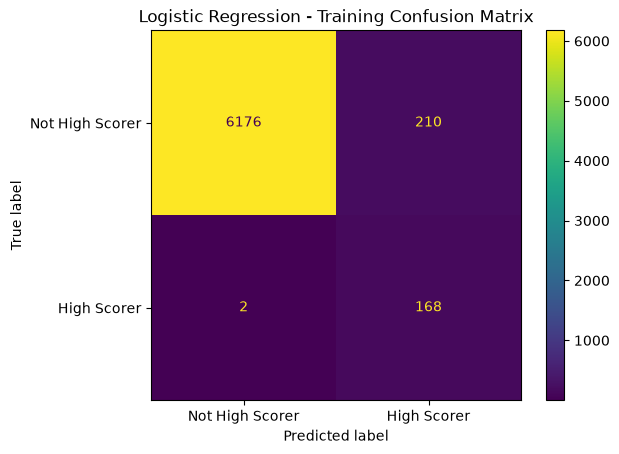

In [41]:
ConfusionMatrixDisplay(
    confusion_matrix=train_cm_logistic,
    display_labels=["Not High Scorer", "High Scorer"]
).plot()

plt.title("Logistic Regression - Training Confusion Matrix")
plt.show()

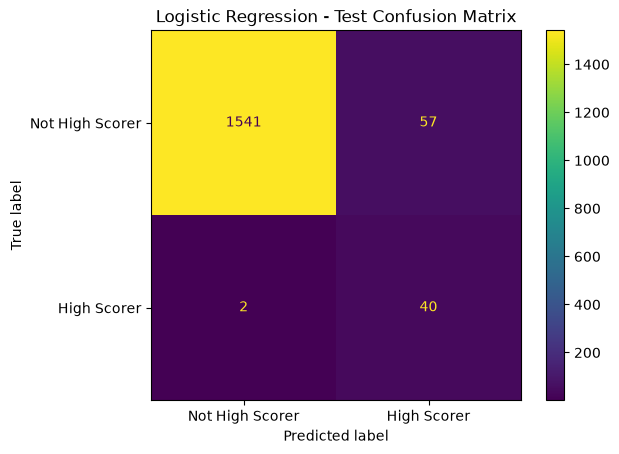

In [42]:
ConfusionMatrixDisplay(
    confusion_matrix=test_cm_logistic,
    display_labels=["Not High Scorer", "High Scorer"]
).plot()

plt.title("Logistic Regression - Test Confusion Matrix")
plt.show()

### Logistic Regression Observation

Logistic Regression performed consistently across the training and test sets, suggesting that the model generalises reasonably well to unseen data.

On the test set, the model correctly identified **40 of the 42 high scorers**, resulting in a recall of **0.95** for the `HighScorer` class. Only **2 high scorers were missed**.

However, the model also produced **57 false positives**, resulting in a lower precision of **0.41** for high scorers. This demonstrates a trade-off between identifying most high scorers and incorrectly classifying some non-high-scorers as high scorers.

The test F1-score for the high-scorer class was **0.58**, compared with **0.61** on the training set. The relatively small difference between training and test performance provides no strong indication of overfitting.

These results will be used as a baseline for comparison with other classification models.

***